# NLP Data Preparation for Text Classification

This notebook prepares any CSV dataset containing text and labels for use with:
- **AWS SageMaker BlazingText** (supervised text classification)
- **AWS SageMaker LDA** (unsupervised topic modeling) — prepared in Part 2

**You only need to change a few things:**
1. The filename of your dataset
2. The name of your text column(s)
3. The name of your label column

Run each cell in order from top to bottom. At the end, you will have a cleaned CSV and a BlazingText-formatted text file ready for the Part 2 notebooks.

**Important:** If you need to start over, use Kernel -> Restart & Clear Output before re-running.

---

## Choosing a Good Text Dataset

### Size Requirements
- **Minimum:** 300 rows (500+ recommended)
- **Columns:** At least one text column and one label column

### Data Quality
- Text should be at least a few words per sample (not just single words)
- Labels should have clear, distinct categories
- Avoid datasets where most samples belong to a single class

### Thresholds This Notebook Uses

| Threshold | Action |
|-----------|--------|
| Fewer than 20 samples per class | Class removed |
| Token count below 5th percentile | Sample removed |
| Token count above 95th percentile | Sample removed |
| Missing text or label | Row removed |
| Empty text after cleaning | Row removed |

### Terminology

| Term | Meaning |
|------|---------|
| Token | A single word in a text sample (approximate word count after cleaning) |
| Label | The category you want to predict (e.g., Positive/Negative) |
| Corpus | The complete collection of text documents in your dataset |
| Stopwords | Common words like "the", "is", "and" that carry little meaning |
| Lemmatization | Reducing words to root form (e.g., "studies" becomes "study") |
| BlazingText format | Each line: `__label__<label> cleaned text here` |
| Vocabulary size | The total count of distinct words remaining after preprocessing |

---
# STEP 1: CONFIGURATION

**EDIT THE VARIABLES BELOW**, then run this cell.

In [1]:
# ============================================================
# CHANGE THESE VALUES FOR YOUR DATASET
# ============================================================

FILE_NAME = "coffee_maker_binary.csv"           # Your CSV file name
TEXT_COLUMNS = ["review"]       # Column(s) containing text to classify
LABEL_COLUMN = "sentiment"       # Column containing the labels to predict

# ============================================================
# OPTIONAL SETTINGS (defaults work well for most projects)
# ============================================================

# Label remapping: Use this if your labels need to be renamed
# Example: {"Like": "Positive", "Dislike": "Negative"}
# Leave empty {} if no remapping is needed
LABEL_MAP = {}

# Minimum samples per class (classes below this threshold are removed)
MIN_SAMPLES_PER_CLASS = 20

# Text preprocessing options
APPLY_STOPWORDS = True       # Remove common words like "the", "is", "and"
REMOVE_EMOJIS = True         # Remove emojis and special symbols

# Outlier removal thresholds (percentile-based)
# Samples shorter than the lower percentile or longer than the upper
# percentile in token count will be removed. Adjust if your dataset
# has a naturally wide or narrow length distribution.
LOWER_PERCENTILE = 5         # Remove samples below this percentile
UPPER_PERCENTILE = 95        # Remove samples above this percentile

# ============================================================
# DO NOT CHANGE ANYTHING BELOW THIS LINE
# ============================================================

# Strip any accidental whitespace from user input
FILE_NAME = FILE_NAME.strip()
LABEL_COLUMN = LABEL_COLUMN.strip()

print("Configuration set:")
print(f"  File:           {FILE_NAME}")
print(f"  Text column(s): {TEXT_COLUMNS}")
print(f"  Label column:   {LABEL_COLUMN}")
print(f"  Stopwords:      {'Enabled' if APPLY_STOPWORDS else 'Disabled'}")
print(f"  Emoji removal:  {'Enabled' if REMOVE_EMOJIS else 'Disabled'}")
print(f"  Outlier range:  {LOWER_PERCENTILE}th to {UPPER_PERCENTILE}th percentile")

Configuration set:
  File:           coffee_maker_binary.csv
  Text column(s): ['review']
  Label column:   sentiment
  Stopwords:      Enabled
  Emoji removal:  Enabled
  Outlier range:  5th to 95th percentile


In [2]:
# ============================================================
# TRACKING VARIABLES (initialized for safety)
# ============================================================
# These track what changes are made during processing.
# Do not modify - they are set automatically by later steps.

RAW_ROWS = 0
RAW_COLS = 0
ROWS_DROPPED_MISSING = 0
ROWS_DROPPED_CLASS_FILTER = 0
ROWS_DROPPED_OUTLIERS = 0
ROWS_DROPPED_EMPTY = 0
CLASSES_REMOVED = 0
NUM_CLASSES = 0
PROBLEM_TYPE = None

print("Tracking variables initialized.")

Tracking variables initialized.


# STEP 2: LOAD REQUIRED LIBRARIES

In [ ]:
# Install any packages not included in the SageMaker environment
!pip install seaborn -q

In [3]:
import subprocess
import sys

def ensure_installed(package_name, import_name=None):
    """Check if a package is installed; if not, install it."""
    if import_name is None:
        import_name = package_name
    try:
        __import__(import_name)
    except ImportError:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])

# Ensure required packages are available
ensure_installed("seaborn")
ensure_installed("emoji")
ensure_installed("nltk")

import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


# Natural Language Processing
import nltk
from nltk.tokenize import RegexpTokenizer
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK data files (one-time setup)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("averaged_perceptron_tagger_eng", quiet=True)

# Emoji handling
import emoji
EMOJI_AVAILABLE = True

# Suppress version-related warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# Set random seed for reproducibility across re-runs
np.random.seed(42)

print("Libraries loaded successfully.")
print(f"  pandas version: {pd.__version__}")
print(f"  numpy version: {np.__version__}")

Libraries loaded successfully.
  pandas version: 2.3.3
  numpy version: 1.26.4


# STEP 3: LOAD AND INSPECT YOUR DATA

In [ ]:
# Load the data
try:
    df = pd.read_csv(FILE_NAME)
except UnicodeDecodeError:
    for encoding in ['utf-8-sig', 'latin1', 'iso-8859-1', 'cp1252']:
        try:
            df = pd.read_csv(FILE_NAME, encoding=encoding)
            print(f"Loaded with {encoding} encoding.")
            break
        except Exception:
            continue
    else:
        raise ValueError("Could not read file. Try saving it as UTF-8.")
except FileNotFoundError:
    print(f"ERROR: Could not find file '{FILE_NAME}'")
    print(f"Make sure the file is in the same folder as this notebook.")
    raise

# Strip whitespace from column names
df.columns = df.columns.str.strip()

# Check if file is empty
if len(df) == 0:
    raise ValueError("CSV file is empty (no data rows).")

# Verify text columns exist
missing_text = [col for col in TEXT_COLUMNS if col not in df.columns]
if missing_text:
    print(f"ERROR: Text column(s) not found: {missing_text}")
    print(f"Available columns: {df.columns.tolist()}")
    raise ValueError(f"Text column(s) not found: {missing_text}")

# Verify label column exists (with case auto-correction)
if LABEL_COLUMN not in df.columns:
    close_matches = [c for c in df.columns if c.lower().strip() == LABEL_COLUMN.lower().strip()]
    if len(close_matches) == 1:
        print(f"Note: Using '{close_matches[0]}' (case-corrected from '{LABEL_COLUMN}')")
        LABEL_COLUMN = close_matches[0]
    else:
        print(f"ERROR: Could not find column '{LABEL_COLUMN}'")
        print(f"Available columns: {df.columns.tolist()}")
        raise ValueError(f"Label column '{LABEL_COLUMN}' not found.")

# Combine multiple text columns into one (if more than one was specified)
if len(TEXT_COLUMNS) == 1:
    # Single text column: reference it directly to avoid a redundant copy
    df["combined_text"] = df[TEXT_COLUMNS[0]]
else:
    df["combined_text"] = df[TEXT_COLUMNS].astype(str).agg(" ".join, axis=1)

# Save initial dimensions
RAW_ROWS = len(df)
RAW_COLS = len(df.columns)

# Warn about very small datasets
if RAW_ROWS < 300:
    print(f"WARNING: The file contains only {RAW_ROWS} rows.")
    print("Text classification typically requires hundreds or thousands of samples.")
    print()

print("=" * 60)
print("DATA LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Rows: {RAW_ROWS:,}")
print(f"Columns: {RAW_COLS}")
print(f"Text column(s): {TEXT_COLUMNS}")
print(f"Label column: {LABEL_COLUMN}")
print()
print("First few rows:")
df.head()

### Data Overview

Review the data loaded above. Consider:
- Does the text column contain meaningful text (sentences, phrases)?
- Does the label column contain clear categories?
- Are there obvious data quality issues (missing values, garbled text)?

# STEP 4: DETECT PROBLEM TYPE AND PREPARE LABELS

The notebook examines your label column to determine the classification type.

### Problem Types

**Binary Classification** - predicting one of two outcomes:
- Positive/Negative, Spam/Not Spam, Yes/No

**Multiclass Classification** - predicting one of three or more categories:
- Product categories, sentiment levels (1-5 stars), department routing

### Detection Rules

1. If the label column has exactly 2 unique values -> Binary Classification
2. If the label column has 3 to 20 unique values -> Multiclass Classification
3. If the label column has more than 20 unique values -> Error (too many classes)

In [ ]:
# Apply label remapping if provided
if LABEL_MAP:
    df[LABEL_COLUMN] = df[LABEL_COLUMN].replace(LABEL_MAP)
    print("Label remapping applied.")

# Remove rows with missing text or labels
initial_size = len(df)
df = df.dropna(subset=["combined_text", LABEL_COLUMN])
ROWS_DROPPED_MISSING = initial_size - len(df)
if ROWS_DROPPED_MISSING > 0:
    print(f"Removed {ROWS_DROPPED_MISSING} rows with missing text or labels.")

# Convert labels to strings for consistent handling
df[LABEL_COLUMN] = df[LABEL_COLUMN].astype(str).str.strip()

# Analyze label column
n_unique = df[LABEL_COLUMN].nunique()

print()
print("=" * 60)
print("ANALYZING LABEL COLUMN")
print("=" * 60)
print(f"Column: {LABEL_COLUMN}")
print(f"Unique values: {n_unique}")
print()

# Check for degenerate case
if n_unique < 2:
    raise ValueError("Label column must have at least 2 unique values.")

# Determine problem type
if n_unique == 2:
    PROBLEM_TYPE = "binary_classification"
    print("Detected: BINARY CLASSIFICATION (two categories)")
elif n_unique <= 20:
    PROBLEM_TYPE = "multiclass_classification"
    print(f"Detected: MULTICLASS CLASSIFICATION ({n_unique} categories)")
else:
    print(f"ERROR: Label column has {n_unique} unique values.")
    print("This is too many for classification (maximum 20).")
    print("Consider grouping categories into fewer buckets.")
    raise ValueError(f"Too many categories ({n_unique}) in label column.")

NUM_CLASSES = n_unique

# Show label distribution
print()
print("Label distribution:")
for label, count in df[LABEL_COLUMN].value_counts().items():
    pct = count / len(df) * 100
    bar = "*" * int(pct / 2)
    print(f"  {label}: {count:,} ({pct:.1f}%) {bar}")

# STEP 5: FILTER UNDERREPRESENTED CLASSES

Classes with too few samples will not have enough data for the model to learn reliably. This step removes any class with fewer than the minimum number of samples.

**Why filter classes?**
If a class has only 5 examples, the model cannot learn meaningful patterns for that category. After train/test splitting, there might be only 1 to 2 test examples, making evaluation meaningless.

In [6]:
print("=" * 60)
print("FILTERING UNDERREPRESENTED CLASSES")
print("=" * 60)

# Count samples per class
class_counts = df[LABEL_COLUMN].value_counts()
valid_classes = class_counts[class_counts >= MIN_SAMPLES_PER_CLASS].index.tolist()
removed_classes = class_counts[class_counts < MIN_SAMPLES_PER_CLASS]

rows_before = len(df)
df = df[df[LABEL_COLUMN].isin(valid_classes)]
rows_after = len(df)
ROWS_DROPPED_CLASS_FILTER = rows_before - rows_after
CLASSES_REMOVED = len(removed_classes)

if CLASSES_REMOVED > 0:
    print(f"Removed {CLASSES_REMOVED} class(es) with fewer than {MIN_SAMPLES_PER_CLASS} samples:")
    for label, count in removed_classes.items():
        print(f"  - '{label}': {count} samples")
    print()
else:
    print("No classes removed. All classes have sufficient samples.")
    print()

# Update class count and problem type
NUM_CLASSES = df[LABEL_COLUMN].nunique()
if NUM_CLASSES == 2 and PROBLEM_TYPE == "multiclass_classification":
    PROBLEM_TYPE = "binary_classification"
    print("Note: Problem type changed to BINARY CLASSIFICATION after filtering.")

# Normalize label names for BlazingText compatibility
# Labels are lowercased and spaces are replaced with underscores
# This ensures consistent label format across all export files
original_labels = df[LABEL_COLUMN].unique().tolist()
label_changes = {}
for orig in original_labels:
    norm = orig.strip().lower().replace(" ", "_")
    if orig != norm:
        label_changes[orig] = norm
df[LABEL_COLUMN] = df[LABEL_COLUMN].str.strip().str.lower().str.replace(" ", "_")

# Show label changes if normalization altered any labels
if label_changes:
    print()
    print("Label normalization (for BlazingText compatibility):")
    for orig, norm in label_changes.items():
        print(f"  '{orig}' -> '{norm}'")
    print()

print(f"Classes retained: {NUM_CLASSES}")
for label, count in df[LABEL_COLUMN].value_counts().items():
    pct = count / len(df) * 100
    print(f"  {label}: {count:,} ({pct:.1f}%)")
print()
print(f"Data shape: {len(df):,} rows")

FILTERING UNDERREPRESENTED CLASSES
No classes removed. All classes have sufficient samples.


Label normalization (for BlazingText compatibility):
  'Negative' -> 'negative'
  'Positive' -> 'positive'

Classes retained: 2
  positive: 2,935 (64.6%)
  negative: 1,610 (35.4%)

Data shape: 4,545 rows


# STEP 6: PREPROCESS TEXT

This step cleans and normalizes the text. Raw text contains noise that can confuse the model.

**What preprocessing does:**
- **Lowercasing**: "Good" and "good" are treated the same
- **URL/HTML removal**: Strips out web links and HTML tags
- **Emoji removal** (optional): Removes emojis and special symbols
- **Tokenization**: Breaks text into individual words (tokens)
- **Part-of-speech tagging**: Identifies whether each word is a noun, verb, adjective, etc.
- **Lemmatization**: Reduces words to root form using part-of-speech context ("studies" becomes "study", "ran" becomes "run")
- **Single-character token removal**: Removes single-character fragments left over from tokenization (e.g., when "don't" is split into "don" and "t", the "t" is removed)
- **Stopword removal** (optional): Filters out common words like "the", "is", "and"

**What are token count outliers?**
Samples that are extremely short (just one word) or extremely long can distort the model. This step removes samples below the lower percentile or above the upper percentile in token count. You can adjust these thresholds in Step 1. Only change percentiles if you are losing too many rows or if the token count histogram in Step 7 shows two distinct text length populations.

**Note on negation:** The default stopword list removes common words including "not", "no", and "nor". For most topic modeling and classification tasks this works well, but if your dataset depends heavily on negation to distinguish categories (e.g., sentiment analysis where "not good" vs. "good" matters), consider setting `APPLY_STOPWORDS = False` in Step 1 and note this decision in your assignment.

**Note on lemmatization:** This notebook uses part-of-speech tagging to improve lemmatization accuracy. For example, POS tagging helps the lemmatizer choose more accurate root forms in most cases, such as recognizing "running" as a verb and reducing it to "run". Without part-of-speech context, the lemmatizer defaults to treating every word as a noun, which produces less accurate results. POS tagging runs on the full token sequence before stopwords are removed, so the tagger has complete sentence context for accurate predictions.

**Note on outlier removal:** If many documents share the same token count, the percentile boundaries may coincide, which means fewer outliers may be removed than expected. Review the removal count reported below the statistics.

In [7]:
# Initialize text processing tools
from nltk.corpus import wordnet
lemmatizer = WordNetLemmatizer()
tokenizer = RegexpTokenizer(r"\w+")
stop_words = set(stopwords.words("english")) if APPLY_STOPWORDS else set()

# Fallback emoji pattern (used only if emoji package is not available)
_emoji_pattern = re.compile("[" 
    u"\U0001F600-\U0001F64F"
    u"\U0001F300-\U0001F5FF"
    u"\U0001F680-\U0001F6FF"
    u"\U0001F1E0-\U0001F1FF"
    u"\U0001F900-\U0001F9FF"
    u"\U0001FA00-\U0001FA6F"
    u"\U0001FA70-\U0001FAFF"
    u"\U00002702-\U000027B0"
    u"\U0000FE00-\U0000FE0F"
    u"\U0000200D"
    "]+", flags=re.UNICODE
)

def _get_wordnet_pos(treebank_tag):
    """Convert NLTK POS tag to WordNet POS tag for accurate lemmatization."""
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

def clean_text(text):
    """Clean and normalize a single text string."""
    text = text.lower()
    # These patterns remove web links and HTML tags. You do not need to edit them.
    text = re.sub(r"http\S+|www\.\S+", "", text)
    text = re.sub(r"<.*?>", "", text)
    if REMOVE_EMOJIS:
        if EMOJI_AVAILABLE:
            text = emoji.replace_emoji(text, replace="")
        else:
            text = _emoji_pattern.sub(r"", text)
    tokens = tokenizer.tokenize(text)
    tokens = [t for t in tokens if len(t) > 1]  # Remove single-character fragments
    # POS tag on full token sequence for accurate context
    tagged = nltk.pos_tag(tokens)
    # Remove stopwords after POS tagging to preserve tagger accuracy
    tagged = [(w, pos) for w, pos in tagged if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w, _get_wordnet_pos(pos)) for w, pos in tagged]
    return " ".join(tokens)

# Warn if stopwords are enabled and labels look like a rating scale
if APPLY_STOPWORDS:
    label_vals = df[LABEL_COLUMN].unique()
    try:
        numeric_labels = sorted([float(v) for v in label_vals])
        if len(numeric_labels) >= 3 and numeric_labels == list(range(int(numeric_labels[0]), int(numeric_labels[-1]) + 1)):
            print("NOTE: Your labels appear to be a numeric rating scale (e.g., 1-5 stars).")
            print("Stopword removal is enabled, which removes negation words like")
            print("\"not\", \"no\", and \"nor\". These words can be important for")
            print("distinguishing sentiment (e.g., \"not good\" vs. \"good\").")
            print("If classification accuracy is poor in Part 2, consider re-running")
            print("with APPLY_STOPWORDS = False in Step 1.")
            print()
    except (ValueError, TypeError):
        pass

# Apply preprocessing
print("Cleaning and preprocessing text...")
print("(This may take a moment for large datasets due to part-of-speech tagging.)")
print()
df["cleaned_text"] = df["combined_text"].astype(str).apply(clean_text)

# Remove rows where cleaning produced empty text
before_empty_check = len(df)
df = df[df["cleaned_text"].str.strip().str.len() > 0]
ROWS_DROPPED_EMPTY = before_empty_check - len(df)
if ROWS_DROPPED_EMPTY > 0:
    print(f"Removed {ROWS_DROPPED_EMPTY} row(s) where all text was removed during cleaning.")
    print()

# Calculate token counts
df["num_tokens"] = df["cleaned_text"].apply(lambda x: len(x.split()))

print("=" * 60)
print("TOKEN COUNT STATISTICS")
print("=" * 60)
print()
print(f"Minimum tokens:  {df['num_tokens'].min()}")
print(f"Maximum tokens:  {df['num_tokens'].max()}")
print(f"Average tokens:  {df['num_tokens'].mean():.1f}")
print(f"Median tokens:   {df['num_tokens'].median():.0f}")

# Calculate and display vocabulary size
all_tokens = " ".join(df["cleaned_text"]).split()
vocab_size = len(set(all_tokens))
print()
print(f"Total tokens in corpus: {len(all_tokens):,}")
print(f"Raw vocabulary size (before outlier removal): {vocab_size:,}")

# Remove token count outliers
low_th, high_th = np.percentile(df["num_tokens"], [LOWER_PERCENTILE, UPPER_PERCENTILE])
low_th = max(low_th, 3)  # Floor: keep samples with at least 3 tokens
before_filter = len(df)
df = df[(df["num_tokens"] >= low_th) & (df["num_tokens"] <= high_th)]
after_filter = len(df)
ROWS_DROPPED_OUTLIERS = before_filter - after_filter

print()
print(f"Token count range kept: {low_th:.0f} to {high_th:.0f}")
print(f"Removed {ROWS_DROPPED_OUTLIERS} outlier samples ({LOWER_PERCENTILE}th-{UPPER_PERCENTILE}th percentile filter)")
print(f"Remaining samples: {after_filter:,}")

# Recalculate vocabulary after outlier removal
all_tokens_final = " ".join(df["cleaned_text"]).split()
vocab_size_final = len(set(all_tokens_final))
print()
print(f"Final vocabulary size (after outlier removal): {vocab_size_final:,} unique words")

Cleaning and preprocessing text...
(This may take a moment for large datasets due to part-of-speech tagging.)

Removed 2 row(s) where all text was removed during cleaning.

TOKEN COUNT STATISTICS

Minimum tokens:  1
Maximum tokens:  443
Average tokens:  29.0
Median tokens:   20

Total tokens in corpus: 131,640
Raw vocabulary size (before outlier removal): 5,296

Token count range kept: 3 to 85
Removed 417 outlier samples (5th-95th percentile filter)
Remaining samples: 4,126

Final vocabulary size (after outlier removal): 4,520 unique words


---
# STEP 7: EXPLORATORY VISUALIZATIONS

These visualizations provide a checkpoint before training. Verify that:
- The dataset remains reasonably balanced after cleaning and filtering
- The token length distribution looks reasonable
- The cleaned text still preserves meaningful language

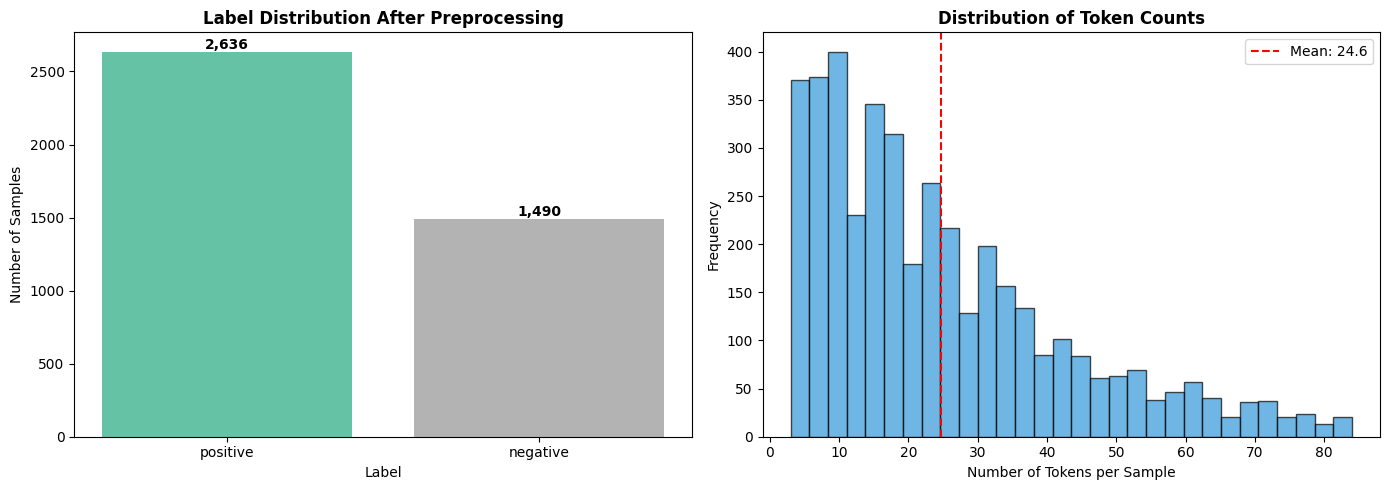

SAMPLE CLEANED TEXTS BY LABEL

Review these samples. Can you tell which label each belongs to
based on the cleaned text alone? If not, the preprocessing may
have removed too much meaningful content.

Label: negative
----------------------------------------
  Example 1: first two week coffee maker work super well start act stop work brew two cup coffee even though want 12 cup make regret buying product recommend
  Example 2: 4th coffee maker like purchase seem problem always occur late two big problem week use first rubber skid stop bottom continually pull move bad leak wa...

Label: positive
----------------------------------------
  Example 1: great product own buy
  Example 2: enjoy gp pour directly cup feature easy clean coffee hot second cup five star



In [8]:
# Visualize label distribution and token counts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Label distribution
label_counts = df[LABEL_COLUMN].value_counts()
colors = plt.cm.Set2(np.linspace(0, 1, len(label_counts)))
axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_title("Label Distribution After Preprocessing", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Label")
axes[0].set_ylabel("Number of Samples")
for i, (label, count) in enumerate(label_counts.items()):
    axes[0].text(i, count + 20, f"{count:,}", ha='center', fontweight='bold')

# Plot 2: Token count distribution
axes[1].hist(df["num_tokens"], bins=30, edgecolor='black', alpha=0.7, color='#3498db')
axes[1].set_title("Distribution of Token Counts", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Number of Tokens per Sample")
axes[1].set_ylabel("Frequency")
axes[1].axvline(df["num_tokens"].mean(), color='red', linestyle='--', label=f'Mean: {df["num_tokens"].mean():.1f}')
axes[1].legend()

plt.tight_layout()
plt.show()

# Show sample cleaned texts
print("=" * 60)
print("SAMPLE CLEANED TEXTS BY LABEL")
print("=" * 60)
print()
print("Review these samples. Can you tell which label each belongs to")
print("based on the cleaned text alone? If not, the preprocessing may")
print("have removed too much meaningful content.")
print()
for label in df[LABEL_COLUMN].unique():
    print(f"Label: {label}")
    print("-" * 40)
    samples = df[df[LABEL_COLUMN] == label]["cleaned_text"].sample(min(2, len(df[df[LABEL_COLUMN] == label])), random_state=42)
    for i, txt in enumerate(samples, 1):
        display_txt = txt[:150] + "..." if len(txt) > 150 else txt
        print(f"  Example {i}: {display_txt}")
    print()

---
# STEP 8: PREPARATION SUMMARY AND RECOMMENDATION

This summary tells you whether your text dataset is ready for export and use in the Part 2 notebooks (BlazingText classification and LDA topic modeling).

In [9]:
print("=" * 60)
print("PREPARATION COMPLETE")
print("=" * 60)

# Summarize what was cleaned
n_rows = len(df)
changes = []
if ROWS_DROPPED_MISSING > 0:
    changes.append(f"Removed {ROWS_DROPPED_MISSING:,} row(s) with missing text or labels")
if CLASSES_REMOVED > 0:
    changes.append(f"Removed {CLASSES_REMOVED} class(es) with too few samples")
if ROWS_DROPPED_EMPTY > 0:
    changes.append(f"Removed {ROWS_DROPPED_EMPTY:,} row(s) with empty text after cleaning")
if ROWS_DROPPED_OUTLIERS > 0:
    changes.append(f"Removed {ROWS_DROPPED_OUTLIERS:,} outlier row(s) based on token count")

if changes:
    print()
    print("What was cleaned:")
    for change in changes:
        print(f"  - {change}")

print()
print(f"Final dataset: {n_rows:,} samples across {NUM_CLASSES} classes")
print(f"Problem type: {PROBLEM_TYPE.replace('_', ' ').title()}")

# vocab_size_final was calculated at the end of Step 6
print(f"Final vocabulary size: {vocab_size_final:,} unique words")



# Show class distribution
print()
print("Final class distribution:")
for label, count in df[LABEL_COLUMN].value_counts().items():
    pct = count / len(df) * 100
    bar = "*" * int(pct / 2)
    print(f"  {label}: {count:,} ({pct:.1f}%) {bar}")

# Evaluate dataset suitability
issues = []

# Check 1: Too few rows
if n_rows < 300:
    issues.append("Very few samples remaining (less than 300)")

# Check 2: Class imbalance
class_pcts = df[LABEL_COLUMN].value_counts(normalize=True)
if class_pcts.max() > 0.90:
    issues.append(f"Severe class imbalance: one class is {class_pcts.max()*100:.1f}% of data")
elif class_pcts.max() > 0.80:
    issues.append(f"Significant class imbalance: one class is {class_pcts.max()*100:.1f}% of data")
elif class_pcts.max() > 0.60:
    print(f"  Note: Moderate class imbalance detected (largest class is {class_pcts.max()*100:.1f}%).")
    print(f"  This is not a blocking issue but may affect minority class prediction.")
    print()

# Check 3: Lost most of the data
retention_rate = n_rows / RAW_ROWS
if retention_rate < 0.3:
    issues.append(f"More than 70% of original data was removed during cleaning")

# Check 4: Very short texts
if df["num_tokens"].median() < 3:
    issues.append("Median token count is very low (less than 3 words per sample)")

# Check 5: Vocabulary too small
if vocab_size_final < 200:
    issues.append(f"Vocabulary size is very small ({vocab_size_final} unique words). Models need variety to detect meaningful patterns.")



# Display recommendation
print()
print("=" * 60)
print("RECOMMENDATION")
print("=" * 60)

if len(issues) == 0:
    print()
    print(">>> PROCEED <<<")
    print()
    print("Your dataset passed all quality checks.")
    print("It is ready for export. Continue to Step 9.")
    RECOMMENDATION = "PROCEED"
elif len(issues) == 1:
    print()
    print(">>> PROCEED WITH CAUTION <<<")
    print()
    print("Your dataset can be used, but there is one concern:")
    print(f"  - {issues[0]}")
    print()
    print("You may continue to Step 9, but model performance may be limited.")
    RECOMMENDATION = "CAUTION"
else:
    print()
    print(">>> STOP - CONSIDER A DIFFERENT DATASET <<<")
    print()
    print("Your dataset has multiple issues that may prevent good results:")
    for issue in issues:
        print(f"  - {issue}")
    print()
    print("Recommendation: Choose a different dataset or consult your instructor.")
    RECOMMENDATION = "STOP"

print()
print("=" * 60)

PREPARATION COMPLETE

What was cleaned:
  - Removed 1 row(s) with missing text or labels
  - Removed 2 row(s) with empty text after cleaning
  - Removed 417 outlier row(s) based on token count

Final dataset: 4,126 samples across 2 classes
Problem type: Binary Classification
Final vocabulary size: 4,520 unique words

Final class distribution:
  positive: 2,636 (63.9%) *******************************
  negative: 1,490 (36.1%) ******************
  Note: Moderate class imbalance detected (largest class is 63.9%).
  This is not a blocking issue but may affect minority class prediction.


RECOMMENDATION

>>> PROCEED <<<

Your dataset passed all quality checks.
It is ready for export. Continue to Step 9.



---
# STEP 9: EXPORT CLEANED FILES

This step creates two output files needed for the Part 2 notebooks:

1. **Cleaned CSV** - the full dataset with original columns plus `cleaned_text`
2. **BlazingText file** - a `.txt` file formatted for AWS SageMaker BlazingText supervised text classification

### BlazingText Format

BlazingText expects a single preprocessed text file where each line contains a label prefix followed by the space-separated tokens:

```
__label__5.0 love coffee maker easy use great product
__label__1.0 terrible broke week waste money
```

The `__label__` prefix is required by the algorithm. Labels are normalized (lowercased, spaces replaced with underscores) for compatibility.

**Note:** The train/validation/test split required by BlazingText will be created in the Part 2 Text Classification notebook. This file contains the full dataset.

**Note on LDA:** The per-class text files needed for LDA topic modeling will be generated in the Part 2 Topic Modeling notebook.

In [ ]:
print("=" * 60)
print("EXPORTING FILES")
print("=" * 60)
print()

# ============================================================
# 1. EXPORT CLEANED CSV
# ============================================================
cleaned_csv_name = FILE_NAME.replace(".csv", "") + "_cleaned.csv"

# Drop intermediate columns that are not needed downstream.
# combined_text is redundant (identical to the review column for single-column datasets).
# num_tokens was only used for outlier filtering during preprocessing.
export_df = df.drop(columns=["combined_text", "num_tokens"], errors="ignore")
export_df.to_csv(cleaned_csv_name, index=False, encoding="utf-8")

print(f"Cleaned CSV created: {cleaned_csv_name}")
print(f"  Rows: {len(export_df):,}")
print(f"  Columns: {list(export_df.columns)}")
print()

# ============================================================
# 2. EXPORT BLAZINGTEXT FORMAT
# ============================================================
# BlazingText supervised mode expects one line per sample:
#   __label__<label> space separated tokens
# See: https://docs.aws.amazon.com/sagemaker/latest/dg/blazingtext.html
# ============================================================
bt_file_name = FILE_NAME.replace(".csv", "") + "_blazingtext.txt"

bt_lines_written = 0
bt_skipped = 0
with open(bt_file_name, "w", encoding="utf-8") as f:
    for _, row in df.iterrows():
        label = str(row[LABEL_COLUMN]).strip()
        text = str(row["cleaned_text"]).strip()
        if not text or not label:
            bt_skipped += 1
            continue
        f.write(f"__label__{label} {text}\n")
        bt_lines_written += 1

print(f"BlazingText file created: {bt_file_name}")
print(f"  Lines: {bt_lines_written:,}")
if bt_skipped > 0:
    print(f"  Skipped: {bt_skipped} (empty text or label)")
print()

# Show sample lines
print("Sample lines from BlazingText file:")
with open(bt_file_name, "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 3:
            break
        display_line = line.strip()
        if len(display_line) > 120:
            display_line = display_line[:120] + "..."
        print(f"  {display_line}")
print()

print("=" * 60)
print("ALL FILES EXPORTED SUCCESSFULLY")
print("=" * 60)
print()
print("Continue to Step 10 to validate your files before using")
print("them in the Part 2 notebooks.")

---
# STEP 10: DATASET READINESS TEST

This step validates that your exported files are ready to be used in the **Part 2** notebooks.

### What This Test Checks

**Cleaned CSV:** File exists, required columns (`cleaned_text` and the label column) are present, no missing values, at least 2 label classes.

**BlazingText file:** File exists, every line starts with `__label__`, line count matches the cleaned CSV, and a sample of lines are well-formed.

Run this cell after Step 9. If you see **FAIL**, address the issues before submitting.

In [ ]:
# ============================================================
# STEP 10: DATASET READINESS TEST
# ============================================================
# Validates exported files for use in Part 2.
# ============================================================

import os

print("=" * 60)
print("DATASET READINESS TEST")
print("=" * 60)
print()

issues = []

# ============================================================
# TEST 1: CLEANED CSV VALIDATION
# ============================================================
print("-" * 40)
print("TEST 1: Cleaned CSV")
print("-" * 40)

cleaned_csv_name = FILE_NAME.replace(".csv", "") + "_cleaned.csv"

if not os.path.exists(cleaned_csv_name):
    issues.append(f"MISSING: {cleaned_csv_name} does not exist")
    print(f"  [FAIL] File not found: {cleaned_csv_name}")
else:
    cleaned_df = pd.read_csv(cleaned_csv_name)
    n_rows_csv = len(cleaned_df)

    print(f"  File: {cleaned_csv_name}")
    print(f"  Rows: {n_rows_csv:,}")
    print(f"  Columns: {len(cleaned_df.columns)}")

    # Check required columns
    if "cleaned_text" not in cleaned_df.columns:
        issues.append("Missing 'cleaned_text' column in cleaned CSV")
    if LABEL_COLUMN not in cleaned_df.columns:
        issues.append(f"Missing '{LABEL_COLUMN}' column in cleaned CSV")

    # Check for missing values in key columns
    if "cleaned_text" in cleaned_df.columns:
        missing_text = cleaned_df["cleaned_text"].isna().sum()
        if missing_text > 0:
            issues.append(f"{missing_text} missing values in 'cleaned_text' column")

    if LABEL_COLUMN in cleaned_df.columns:
        missing_labels = cleaned_df[LABEL_COLUMN].isna().sum()
        if missing_labels > 0:
            issues.append(f"{missing_labels} missing values in '{LABEL_COLUMN}' column")

    # Check number of classes
    if LABEL_COLUMN in cleaned_df.columns:
        n_classes = cleaned_df[LABEL_COLUMN].nunique()
        print(f"  Label classes: {n_classes}")
        if n_classes < 2:
            issues.append("Fewer than 2 label classes. Classification requires at least 2.")

        # Show class distribution
        print()
        print("  Class distribution:")
        for label, count in cleaned_df[LABEL_COLUMN].value_counts().items():
            pct = count / n_rows_csv * 100
            print(f"    {label}: {count:,} ({pct:.1f}%)")

print()

# ============================================================
# TEST 2: BLAZINGTEXT FILE VALIDATION
# ============================================================
print("-" * 40)
print("TEST 2: BlazingText File")
print("-" * 40)

bt_file_name = FILE_NAME.replace(".csv", "") + "_blazingtext.txt"

if not os.path.exists(bt_file_name):
    issues.append(f"MISSING: {bt_file_name} does not exist")
    print(f"  [FAIL] File not found: {bt_file_name}")
else:
    # Read and validate every line
    bt_total_lines = 0
    bt_bad_lines = 0
    bt_empty_text_lines = 0
    bt_labels_found = set()
    bt_sample_lines = []

    with open(bt_file_name, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, 1):
            stripped = line.strip()
            if not stripped:
                continue
            bt_total_lines += 1

            # Check __label__ prefix
            if not stripped.startswith("__label__"):
                bt_bad_lines += 1
                if bt_bad_lines <= 3:
                    issues.append(f"Line {line_num} missing __label__ prefix: {stripped[:60]}...")
                continue

            # Check that there is text after the label
            parts = stripped.split(" ", 1)
            if len(parts) < 2 or not parts[1].strip():
                bt_empty_text_lines += 1
            else:
                # Extract label for tracking
                label = parts[0].replace("__label__", "")
                bt_labels_found.add(label)

            # Collect samples
            if len(bt_sample_lines) < 3:
                bt_sample_lines.append(stripped)

    print(f"  File: {bt_file_name}")
    print(f"  Total lines: {bt_total_lines:,}")
    print(f"  Labels found: {sorted(bt_labels_found)}")

    # Validate line count matches CSV
    if os.path.exists(cleaned_csv_name) and "n_rows_csv" in dir():
        if bt_total_lines != n_rows_csv:
            issues.append(
                f"Line count mismatch: BlazingText file has {bt_total_lines:,} lines "
                f"but cleaned CSV has {n_rows_csv:,} rows"
            )

    # Report bad lines
    if bt_bad_lines > 0:
        issues.append(f"{bt_bad_lines} line(s) missing the __label__ prefix")

    # Report empty text lines
    if bt_empty_text_lines > 0:
        issues.append(f"{bt_empty_text_lines} line(s) have a label but no text content")

    # Show sample lines
    print()
    print("  Sample lines:")
    for sample in bt_sample_lines:
        display = sample[:120] + "..." if len(sample) > 120 else sample
        print(f"    {display}")

print()

# ============================================================
# RESULTS SUMMARY
# ============================================================
print("=" * 60)
print("READINESS TEST RESULTS")
print("=" * 60)
print()

if issues:
    print("ERRORS:")
    for issue in issues:
        print(f"  [FAIL] {issue}")
    print()

# Final verdict
print("-" * 40)
if len(issues) == 0:
    print("RESULT: PASS")
    print("Your files are ready for the Part 2 notebooks.")
else:
    print(f"RESULT: FAIL ({len(issues)} error(s))")
    print("Your dataset has issues that will cause problems in Part 2.")
    print("Address the errors above before submitting.")
    print()
    print("Common fixes:")
    print("  - Choose a dataset with longer text samples (10+ words per sample)")
    print("  - Choose a dataset with more rows (500+)")
    print("  - Choose a dataset with richer vocabulary")
    print("  - If using synthetic data, increase word variety and sentence length")
    print("  - Ensure each label class has at least 50 documents")
    print()
    print("See the Troubleshooting section at the bottom of this notebook for more help.")

print()
print("=" * 60)

---
## Troubleshooting

**"Text column(s) not found"**
- Check the spelling of your text column name
- Column names are case-sensitive ("Review" is different from "review")
- Look at the list of available columns in the error message

**"Label column not found"**
- Check the spelling of your label column name
- Make sure it matches exactly (including capitalization)

**"Too many categories in label column"**
- Your label column has more than 20 unique values
- Consider grouping similar categories or using a different label column

**"Label column must have at least 2 unique values"**
- Every row has the same label, or all labels are missing
- Check that you selected the correct label column

**"Very few samples remaining"**
- Too many rows were removed during cleaning
- Try a larger dataset or adjust the MIN_SAMPLES_PER_CLASS threshold

**"Severe class imbalance"**
- One class dominates the dataset (e.g., 95% positive, 5% negative)
- The model may predict the majority class for everything
- Try to find a more balanced dataset

**Token counts are very low**
- Your text may already be heavily preprocessed or very short
- Consider using raw text instead of pre-cleaned text
- Or use a dataset with longer text samples

**Preprocessing is slow**
- Part-of-speech tagging adds processing time compared to basic lemmatization
- This is normal for datasets over 5,000 rows and may take 1-2 minutes
- The accuracy improvement is worth the wait

**Questions?**
- Consult your instructor or TA for help choosing an appropriate dataset